In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import os
import re
from pycontrails.core import GeoVectorDataset
from pycontrails.models.gpat.gpat import create_jobs_df, filter_jobs_df, load_fl_df, load_pl_df, load_chem_ds, load_chem_da, plot_heatmap, anim_chem, mc_test, boxm_test

In [2]:
outputs_dir = f"{os.getcwd()}/outputs/"

In [3]:
# Filter criteria
criteria = {
        # "n_ac": 3,
        # "rt_fl": (pd.Timedelta(minutes=30), pd.Timedelta(hours=2)),
        # "date_created": (pd.Timestamp("2024-11-16"), pd.Timestamp("2024-11-17")),
        "job_id": 'id_vs_plume_NA_1_1000_0_2_0.01_0.05'
    }

In [4]:
jobs_df = create_jobs_df(outputs_dir)


In [5]:
filtered_df = filter_jobs_df(jobs_df, criteria)

job_ids = filtered_df.index.values
 
filtered_df



,t0_fl,rt_fl,ts_fl,ac_type,fl0_speed,fl0_heading,fl0_coords0,sep_dist,n_ac,dt_integration,...,traj_gen_proc,gen_met_proc,bg_chem_proc,ac_perf_proc,emissions_proc,sim_plumes_proc,plume_to_grid_proc,run_cc_proc,run_boxm_proc,gen_outputs_proc
job_id,,,,,,,,,,,,,,,,,,,,,
id_vs_plume_NA_1_1000_0_2_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",1,0 days 00:02:00,...,0.011706,5.388184,0.265193,0.03003,0.05452,1.010974,331.359741,0.000001,8.265082,0


In [6]:
fl_df = load_fl_df(job_ids, outputs_dir)

fl_df


,longitude,latitude,altitude,time,air_temperature,specific_humidity,true_airspeed,flight_id,aircraft_mass,engine_efficiency,...,NO,NO2,CO,HCHO,CH3CHO,C2H4,C3H6,C2H2,BENZENE,waypoint
job_id,,,,,,,,,,,,,,,,,,,,,
id_vs_plume_NA_1_1000_0_2_0.01_0.05,-32.900000,47.100000,12500.0,2022-01-20 13:00:00,219.539390,0.000039,100.099398,0.0,61207.994419,0.098938,...,1.712263,0.090119,0.061216,0.000717,0.000239,0.000896,0.000239,0.000239,0.000119,0
id_vs_plume_NA_1_1000_0_2_0.01_0.05,-32.787015,47.175907,12500.0,2022-01-20 13:02:00,219.548811,0.000039,100.027041,0.0,61083.237409,0.098900,...,1.711931,0.090102,0.061217,0.000717,0.000239,0.000896,0.000239,0.000239,0.000119,1
id_vs_plume_NA_1_1000_0_2_0.01_0.05,-32.674029,47.251813,12500.0,2022-01-20 13:04:00,219.558331,0.000039,99.954646,0.0,60958.496523,0.098861,...,1.711596,0.090084,0.061218,0.000717,0.000239,0.000896,0.000239,0.000239,0.000119,2
id_vs_plume_NA_1_1000_0_2_0.01_0.05,-32.561044,47.327720,12500.0,2022-01-20 13:06:00,219.567949,0.000038,99.882214,0.0,60833.771972,0.098823,...,1.711256,0.090066,0.061219,0.000717,0.000239,0.000896,0.000239,0.000239,0.000119,3
id_vs_plume_NA_1_1000_0_2_0.01_0.05,-32.448059,47.403627,12500.0,2022-01-20 13:08:00,219.577666,0.000038,99.809746,0.0,60709.063967,0.098784,...,1.710912,0.090048,0.061219,0.000717,0.000239,0.000896,0.000239,0.000239,0.000119,4
id_vs_plume_NA_1_1000_0_2_0.01_0.05,-32.335074,47.479533,12500.0,2022-01-20 13:10:00,219.587482,0.000038,99.737241,0.0,60584.372717,0.098746,...,1.710564,0.090030,0.061220,0.000717,0.000239,0.000896,0.000239,0.000239,0.000119,5
id_vs_plume_NA_1_1000_0_2_0.01_0.05,-32.222088,47.555440,12500.0,2022-01-20 13:12:00,219.597396,0.000037,99.664701,0.0,60459.698433,0.098707,...,1.710212,0.090011,0.061221,0.000717,0.000239,0.000896,0.000239,0.000239,0.000119,6
id_vs_plume_NA_1_1000_0_2_0.01_0.05,-32.109103,47.631346,12500.0,2022-01-20 13:14:00,219.607410,0.000037,99.664701,0.0,60335.041324,0.098707,...,1.710212,0.090011,0.061221,0.000717,0.000239,0.000896,0.000239,0.000239,0.000119,7


In [7]:
pl_df = load_pl_df(job_ids, outputs_dir)
pl_df.columns

pl_df

,flight_id,waypoint,fuel_flow,fuel_burn,true_airspeed,CO2,H2O,SO2,NO,NO2,...,longitude,latitude,level,width,heading,sigma_yy,sigma_zz,sin_a,cos_a,altitude
job_id,,,,,,,,,,,,,,,,,,,,,
id_vs_plume_NA_1_1000_0_2_0.01_0.05,0.0,0,1.039642,124.757011,100.099398,394.232154,153.451123,0.104796,1.712263,0.090119,...,-32.900000,47.100000,178.645172,81.026358,NaN,8.206588e+02,433.664232,NaN,NaN,12500.0
id_vs_plume_NA_1_1000_0_2_0.01_0.05,0.0,0,1.039642,124.757011,100.099398,394.232154,153.451123,0.104796,1.712263,0.090119,...,-32.900000,47.100000,178.645172,143.604196,44.595919,2.577771e+03,554.828465,0.702102,0.712076,12500.0
id_vs_plume_NA_1_1000_0_2_0.01_0.05,0.0,1,1.039507,124.740886,100.027041,394.181199,153.431289,0.104782,1.711931,0.090102,...,-32.787015,47.175907,178.645172,81.024516,44.595919,8.206215e+02,433.586506,0.702102,0.712076,12500.0
id_vs_plume_NA_1_1000_0_2_0.01_0.05,0.0,0,1.039642,124.757011,100.099398,394.232154,153.451123,0.104796,1.712263,0.090119,...,-32.900000,47.100000,178.645172,217.858458,44.637171,5.932788e+03,675.992697,0.702615,0.711570,12500.0
id_vs_plume_NA_1_1000_0_2_0.01_0.05,0.0,1,1.039507,124.740886,100.027041,394.181199,153.431289,0.104782,1.711931,0.090102,...,-32.787015,47.175907,178.645172,143.595882,44.595919,2.577472e+03,554.673011,0.702102,0.712076,12500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_vs_plume_NA_1_1000_0_2_0.01_0.05,0.0,6,1.038809,124.657109,99.664701,393.916464,153.328244,0.104712,1.710212,0.090011,...,-32.222088,47.555440,178.645172,10378.935209,44.803278,1.346529e+07,7433.612533,0.704675,0.709530,12500.0
id_vs_plume_NA_1_1000_0_2_0.01_0.05,0.0,7,1.038809,124.657109,99.664701,393.916464,153.328244,0.104712,1.710212,0.090011,...,-32.109103,47.631346,178.645172,10123.440425,44.803278,1.281051e+07,7308.383655,0.704675,0.709530,12500.0
id_vs_plume_NA_1_1000_0_2_0.01_0.05,0.0,6,1.038809,124.657109,99.664701,393.916464,153.328244,0.104712,1.710212,0.090011,...,-32.222088,47.555440,178.645172,10633.591704,44.845080,1.413416e+07,7554.309356,0.705192,0.709016,12500.0


In [8]:
chem_ds = load_chem_ds(job_ids, outputs_dir)

chem_ds


/user/home/kt16229/BOXM/scratch/miniconda3/envs/contrails/lib/python3.12/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


[<xarray.Dataset> Size: 10GB
 Dimensions:          (job_id: 1, level: 3, longitude: 22, latitude: 21,
                       time: 21601, species: 219, emi_species: 9,
                       photol_params: 5, photol_coeffs: 5, therm_coeffs: 5,
                       species_out: 13)
 Coordinates:
   * job_id           (job_id) object 8B 'id_vs_plume_NA_1_1000_0_2_0.01_0.05'
   * level            (level) float64 24B 165.1 178.6 193.3
   * longitude        (longitude) float64 176B -33.0 -32.95 ... -32.0 -31.95
   * latitude         (latitude) float64 168B 47.0 47.05 47.1 ... 47.9 47.95 48.0
   * time             (time) datetime64[ns] 173kB 2022-01-20T12:00:00 ... 2022...
     air_pressure     (level, longitude, latitude) float64 11kB ...
     altitude         (level, longitude, latitude) float64 11kB ...
   * species          (species) <U10 9kB 'O1D' 'O' 'OH' ... 'EMPOA' 'P2007'
   * emi_species      (emi_species) <U7 252B 'NO' 'NO2' 'CO' ... 'C2H2' 'BENZENE'
 Dimensions without coordina

<xarray.DataArray 'Y' ()> Size: 8B
array(0.32572213)
Coordinates:
    level         float64 8B 178.6
    longitude     float64 8B -32.9
    latitude      float64 8B 47.1
    air_pressure  float64 8B ...
    altitude      float64 8B ...
    species_out   <U4 16B 'NO'

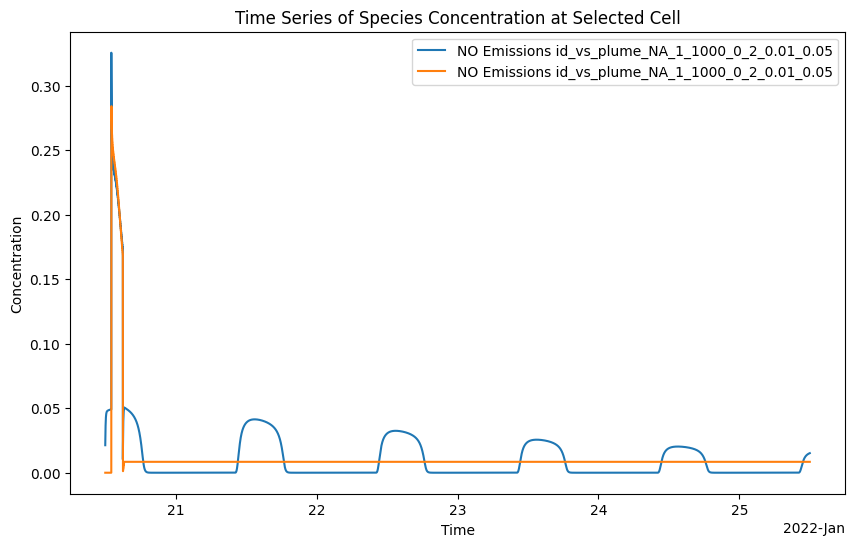

In [9]:
chem_da = []
emi_da = []
# Create a figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 6))

for job, ds in enumerate(chem_ds):
    chem_ds[job] = chem_ds[job].assign_coords(species_out=chem_ds[job].attrs["species_out"])
    chem_da.append(chem_ds[job]["Y"])

    emi_da.append(chem_ds[job]["emi"])

    chem_da_cell = chem_da[job].sel(level=chem_da[0].level[1], longitude=-32.9, latitude=47.1, method='nearest')
    emi_da_cell = emi_da[job].sel(level=emi_da[0].level[1], longitude=-32.9, latitude=47.1, method='nearest')

    NO_data = chem_da_cell.sel(species_out="NO")
    NO2_data = chem_da_cell.sel(species_out="NO2")
    O3_data = chem_da_cell.sel(species_out="O3")

    NO_emi_data = emi_da_cell.sel(emi_species="NO")
    NO2_emi_data = emi_da_cell.sel(emi_species="NO2")

    # Plot the time series data
    #NO_data.plot(ax=ax, label=f"NO {chem_da_cell['job_id'].values[0]}")
    NO_data.plot(ax=ax, label=f"NO Emissions {emi_da_cell['job_id'].values[0]}")
    NO_emi_data.plot(ax=ax, label=f"NO Emissions {emi_da_cell['job_id'].values[0]}")

# Add labels and legend
ax.set_xlabel('Time')
ax.set_ylabel('Concentration')
ax.set_title('Time Series of Species Concentration at Selected Cell')
ax.legend()

# plt.show()
pd.set_option('display.max_rows', 500)
NO_df = NO_data.to_dataframe()
NO_df

NO_data.max()


In [10]:

# chem_ds_stacked = chem_ds.stack(
#             {"cell": ["level", "longitude", "latitude"]}
#         )
# chem_ds_stacked = chem_ds_stacked.reset_index("cell")

# chem_ds_stacked
 

In [11]:

# max_emi_cell = chem_ds_stacked["emi"].mean(dim="time").argmax()#.item()
# print(max_emi_cell)
# # find cell that has max emissions averaged over time in it
# cell_chem_ds = chem_ds_stacked.sel(job_id=job_ids[0], cell=max_emi_cell)
# cell_chem_ds
# # Select the emissions for the specified species
# emi_data = cell_chem_ds["emi"].sel(emi_species="NO")
# chem_data = cell_chem_ds["Y"].sel(species_out="NO")
# emi_data.plot()
# chem_data.plot()

# # # Convert time and emi data to pandas Series
# # ts = 0
# # time_series = pd.Series(emi_data["time"].values)
# # emi_series = pd.Series(emi_data.values)

# # # Print time and emi values side by side
# # for time, emi in zip(time_series, emi_series):
# #     ts += 1
# #     print(f"TS: {ts}, Time: {time}, EMI: {emi}")

# for s, species in enumerate(chem_ds["species"].values):
#     print(chem_ds["bg_chem"].isel(level=1,latitude=0,longitude=0, species=s).values)



In [12]:
#anim_chem(job_ids[0], jobs_df, fl_df, pl_df, chem_ds[0], var1="emi", var2="NO", level=chem_da[0].level[1], resample_freq="2min")

In [13]:
# vecmass, gridmass, mc = mc_test(job_ids[0], jobs_df, fl_df, pl_df, chem_ds)
# mc

In [14]:
path = '/user/work/kt16229/pycontrails_kt/pycontrails/models/gpat/'

cell_chem_ds = boxm_test(path, job_ids[0], 0, chem_ds)

# dj_data = cell_chem_ds["DJ"].sel(photol_coeffs=3)
# dj_orig_data = cell_chem_ds["DJ_orig"].sel(photol_coeffs=3)
# dj_data.plot()
# dj_orig_data.plot()

chem_data = cell_chem_ds["Y"].sel(species_out="NO")
chem_orig_data = cell_chem_ds["Y_orig"].sel(species_out="NO")
chem_data.plot()
chem_orig_data.plot()


AttributeError: 'list' object has no attribute 'stack'